In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [ ]:
# Criando o Dataframe com o retorno dos preços de fechamento em Log
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers=tickers_yfinance, 
    start="2021-07-01", 
    end="2022-06-30", 
    auto_adjust=True
)

df_fechamento = dados_brutos['Close'].copy()

df_fechamento = df_fechamento.ffill()

df_consolidado = np.log(df_fechamento)

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]

df_consolidado.index = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Matriz em log estruturada: {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")

df_consolidado

In [ ]:
# Criando a matriz de correlação

# df_consolidado = pd.concat(lista_log_limpa, axis=1)

matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

In [ ]:
# Criando uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do seu DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeitamos H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

In [36]:
cesta_definitiva = df_consolidado.drop(columns=[])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.2184,0.0100,0.0,0.1000
1,ALOS3,0.7023,0.0100,0.0,0.1000
2,AXIA3,0.6636,0.0256,0.0,0.0847
3,B3SA3,0.1894,0.0803,0.0,0.1000
4,BBAS3,0.5902,0.0100,0.0,0.1000
5,BBDC4,0.0693,0.0424,0.0,0.1000
6,BBSE3,0.8641,0.0100,0.0,0.1000
7,BPAC11,0.2755,0.0100,0.0,0.1000
8,BRAV3,0.1045,0.0359,0.0,0.1000
9,CEAB3,0.9374,0.0100,0.0,0.1000


In [38]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['B3SA3', 'CSMG3', 'EQTL3', 'RENT3', 'VALE3', 'SUZB3'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

Pares cointegrados encontrados: 50
Ativos na cesta do Johansen: 44


,Ativo 1,Ativo 2,Estatística Traço,V.C. Traço (95%),Rejeita r=0 (Traço)?,Estatística Max-Eigen,V.C. Max-Eigen (95%),Rejeita r=0 (Eigen)?,Beta (Ativo 2)
0,TIMS3,VIVT3,29.51,15.49,Sim,26.79,14.26,Sim,-0.6653
1,CURY3,UGPA3,24.33,15.49,Sim,17.34,14.26,Sim,-1.1859
2,BBDC4,CURY3,23.87,15.49,Sim,17.37,14.26,Sim,-0.5823
3,ITSA4,TOTS3,20.99,15.49,Sim,17.64,14.26,Sim,-0.3327
4,DIRR3,UGPA3,20.93,15.49,Sim,13.33,14.26,Não,-0.9550
5,BPAC11,ITUB4,20.93,15.49,Sim,18.38,14.26,Sim,-1.1624
6,CSAN3,UGPA3,20.05,15.49,Sim,14.83,14.26,Sim,-0.9957
7,RADL3,UGPA3,19.84,15.49,Sim,16.27,14.26,Sim,-1.6213
8,CSAN3,CURY3,19.10,15.49,Sim,14.32,14.26,Sim,-0.8842
9,BBDC4,BPAC11,19.03,15.49,Sim,13.41,14.26,Não,-0.4285


In [ ]:
resultados_meia_vida = []

print("Calculando a Meia-Vida correta usando a subtração pura do Beta original...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)'] # Lemos o sinal real (seja positivo ou negativo)
    
    try:
        # 1. Monta o spread respeitando a fórmula padrão: Ativo 1 - (Beta * Ativo 2)
        # Se o beta for negativo, o Python fará a soma automaticamente por regra de sinal
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # 2. Prepara as defasagens para a regressão
        spread_ontem = spread.shift(1)
        delta_spread = spread.diff()
        df_reg = pd.DataFrame({'Y': delta_spread, 'X': spread_ontem}).dropna()
        
        # 3. Executa a regressão com constante
        X_reg = sm.add_constant(df_reg['X'])
        modelo_ou = sm.OLS(df_reg['Y'], X_reg).fit()
        lambda_coef = modelo_ou.params['X']
        
        # 4. Calcula a Meia-Vida real
        if lambda_coef < 0:
            hl_resultado = np.round(-np.log(2) / lambda_coef, 2)
        else:
            hl_resultado = "Divergente"
            
        resultados_meia_vida.append({
            'Par': f"{at1} x {at2}",
            'Meia-Vida (Dias Úteis)': hl_resultado
        })
            
    except Exception:
        continue

# Atualiza o dataframe de estatísticas na memória
df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
print("Cálculo corrigido com sucesso!")

df_estatistica_pares

In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Definimos lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS 74 PARES
# ==============================================================================
resultados_hurst = []

print("Calculando o Expoente de Hurst Estável para os 74 pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Monta o spread correto (Soma algébrica nativa do Johansen)
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

In [ ]:
# 1. Criamos uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()

# 2. SEGREDO AQUI: Criamos a coluna 'Par' idêntica às outras tabelas para servir de elo de ligação
df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 3. Isolamos as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 4. Fazemos o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 5. Reorganizamos a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 6. Ordenamos o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

In [ ]:
# ==============================================================================
# FILTRAGEM DO GRUPO DE ELITE PARA O BACKTEST (TCC)
# ==============================================================================

# 1. Garantimos que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplicamos as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 20 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50

# 3. Criamos o DataFrame filtrado com os pares eleitos (os seus "Pares Verdes")
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordenamos pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

In [ ]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2021-07-01':'2022-06-30'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados do seu df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread (Soma) e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

In [ ]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2022-07-01",
                          end="2022-12-31", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Z-Score com beta ESTÁTICO do Johansen ─────────────────────────────
        # Parâmetros fixos calculados na estimação
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # Spread do trading com mesmo beta estático
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (só para hedge ratio na execução) ──────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"Período de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading

In [59]:
# ==============================================================================
# TABELA DE RESUMO DE TRADES — usando df_historico_trading (Kalman + parâmetros da estimação)
# ==============================================================================

DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Gerencia posição comprada (z cruzou -2) ───────────────────────
        if estava_comprado:
            if z_atual >= DESVIO_SAIDA or z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Gerencia posição vendida (z cruzou +2) ────────────────────────
        if estava_vendido:
            if z_atual <= DESVIO_SAIDA or z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

Varredura concluída! 33 pares analisados.


,Par,Hurst,Meia-Vida,Quantidade de Trades
0,CURY3 x DIRR3,0.2056,14.77,37
1,CURY3 x ITUB4,0.4651,23.61,24
2,BBDC4 x CSAN3,0.2171,20.31,18
3,BPAC11 x CURY3,0.3792,20.78,16
4,BBDC4 x CURY3,0.3444,17.27,12
5,ITSA4 x KLBN11,0.3007,28.76,11
6,BBDC4 x RADL3,0.2796,16.32,10
7,BBDC4 x DIRR3,0.2618,14.45,8
8,CURY3 x SANB11,0.3632,19.82,6
9,BBDC4 x RAIL3,0.2266,19.20,4


In [60]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

Par                               média      min      max      status
──────────────────────────────────────────────────────────────────────
GGBR4 x UGPA3                      0.75    -0.65     3.11        ✓ OK
CSAN3 x UGPA3                     -1.45    -2.74    -0.00        ✓ OK
RADL3 x UGPA3                     -0.50    -1.92     0.85        ✓ OK
RAIL3 x UGPA3                      0.02    -1.67     1.43        ✓ OK
DIRR3 x UGPA3                      0.85    -1.24     2.62        ✓ OK
CYRE3 x UGPA3                     -0.59    -1.72     0.60        ✓ OK
CSAN3 x DIRR3                      0.25    -1.62     1.89        ✓ OK
UGPA3 x VIVT3                     -0.12    -1.31     0.88        ✓ OK
BBDC4 x GGBR4                     -0.47    -2.85     1.21        ✓ OK
TIMS3 x UGPA3                      0.58    -0.46     1.57        ✓ OK
CURY3 x DIRR3                      2.84    -0.90     5.39  ✗ DIVERGIU
CSAN3 x CURY3                      0.87    -1.73     2.59        ✓ OK
CURY3 x UGPA3      

In [61]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

Pares válidos   : 28
Pares excluídos : 5

Excluídos por divergência do spread:
  CURY3 x DIRR3                   média z-score = 2.84
  BBDC4 x CSAN3                   média z-score = -1.74
  ITSA4 x KLBN11                  média z-score = -1.83
  BPAC11 x CURY3                  média z-score = 2.05
  CURY3 x ITUB4                   média z-score = 2.26


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,GGBR4 x UGPA3,GGBR4,UGPA3,16.73,9.90,1.2897,15.67,0.0089
1,CSAN3 x UGPA3,CSAN3,UGPA3,20.05,14.83,-0.9957,21.65,0.0963
2,RADL3 x UGPA3,RADL3,UGPA3,19.84,16.27,-1.6213,22.93,0.1078
3,RAIL3 x UGPA3,RAIL3,UGPA3,18.96,12.76,-0.9860,19.36,0.1298
4,DIRR3 x UGPA3,DIRR3,UGPA3,20.93,13.33,-0.9550,16.12,0.1402
5,CYRE3 x UGPA3,CYRE3,UGPA3,16.31,13.77,-2.2697,21.70,0.1542
6,CSAN3 x DIRR3,CSAN3,DIRR3,18.21,13.75,-1.0087,20.20,0.1686
7,UGPA3 x VIVT3,UGPA3,VIVT3,15.84,11.70,0.6442,28.51,0.1773
8,BBDC4 x GGBR4,BBDC4,GGBR4,17.16,10.81,-0.9254,16.66,0.1897
9,TIMS3 x UGPA3,TIMS3,UGPA3,16.38,10.29,0.9623,28.68,0.2022


In [62]:
MAX_POR_ATIVO = 2
contagem        = {}
pares_limitados = []

for _, linha in df_pares_validos.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    c1  = contagem.get(at1, 0)
    c2  = contagem.get(at2, 0)

    if c1 < MAX_POR_ATIVO and c2 < MAX_POR_ATIVO:
        pares_limitados.append(linha)
        contagem[at1] = c1 + 1
        contagem[at2] = c2 + 1
    else:
        print(f"  [LIMITADO] {linha['Par']}")

df_pares_validos = pd.DataFrame(pares_limitados).reset_index(drop=True)
print(f"\nPares após limite: {len(df_pares_validos)}")

  [LIMITADO] RADL3 x UGPA3
  [LIMITADO] RAIL3 x UGPA3
  [LIMITADO] DIRR3 x UGPA3
  [LIMITADO] CYRE3 x UGPA3
  [LIMITADO] UGPA3 x VIVT3
  [LIMITADO] TIMS3 x UGPA3
  [LIMITADO] CSAN3 x CURY3
  [LIMITADO] CURY3 x UGPA3
  [LIMITADO] ENGI11 x GGBR4
  [LIMITADO] BBDC4 x UGPA3
  [LIMITADO] BBDC4 x DIRR3
  [LIMITADO] BBDC4 x RADL3
  [LIMITADO] DIRR3 x PRIO3
  [LIMITADO] DIRR3 x KLBN11
  [LIMITADO] PRIO3 x UGPA3
  [LIMITADO] BBDC4 x ITUB4
  [LIMITADO] BBDC4 x CURY3
  [LIMITADO] CURY3 x SANB11
  [LIMITADO] BBDC4 x BPAC11

Pares após limite: 9


═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 9
Retorno acumulado líquido : 4.47%
Retorno médio anualizado  : 9.04%
Volatilidade anualizada   : 6.85%
Sharpe anualizado         : 1.3208
Maximum Drawdown          : -2.98%

Retorno acumulado por par:
CSAN3 x UGPA3     -6.71
ENEV3 x SANB11    -5.18
BBDC4 x GGBR4     -4.39
GGBR4 x UGPA3     -2.81
DIRR3 x USIM5      0.00
CSAN3 x DIRR3      0.00
RAIL3 x SANB11    13.51
BRAV3 x ENGI11    19.69
BBDC4 x RAIL3     25.51

Pares lucrativos: 3
Pares com perda : 4


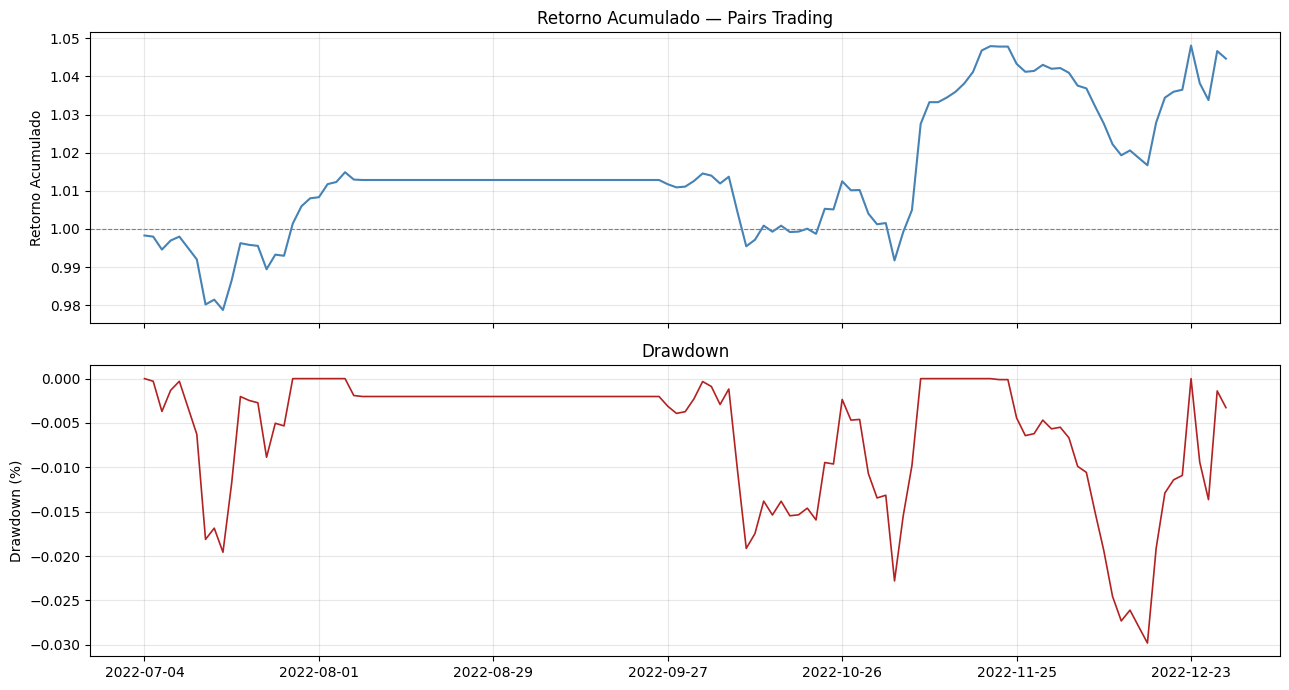

In [63]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# ── Exportação dos resultados do Período para Excel ───────────────────────────
ARQUIVO = "periodo_1_jul2021_dez2022.xlsx"

# ── Número total de trades ────────────────────────────────────────────────────
total_trades = 0
for par in df_pares_validos['Par']:
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z = df_historico_trading[col_z]
    posicao = 0
    dias_em_posicao = 0
    meia_vida_par = int(np.ceil(
        df_pares_validos.loc[df_pares_validos['Par'] == par, 'Meia-Vida (Dias Úteis)'].values[0]
    ))
    for z_atual in z:
        nova_posicao = posicao
        if posicao == 0:
            if z_atual >= ENTRADA:
                nova_posicao = -1; dias_em_posicao = 0
            elif z_atual <= -ENTRADA:
                nova_posicao = +1; dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_atual <= SAIDA or z_atual <= -STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
            elif posicao == -1:
                if -SAIDA <= z_atual <= SAIDA or z_atual >= STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
        if nova_posicao == 0 and posicao != 0:
            total_trades += 1
            dias_em_posicao = 0
        posicao = nova_posicao

# ── Aba 5: Estatísticas resumidas ─────────────────────────────────────────────
df_estatisticas = pd.DataFrame([{
    'Período de Estimação'       : 'Jul/2021 – Jun/2022',
    'Período de Trading'         : 'Jul/2022 – Dez/2022',
    'Pares Operados'             : len(df_pares_validos),
    'Total de Trades'            : total_trades,
    'Retorno Acumulado (%)'      : round((retorno_acumulado.iloc[-1] - 1) * 100, 2),
    'Retorno Anualizado (%)'     : round(retorno_carteira.mean() * 252 * 100, 2),
    'Volatilidade Anualizada (%)': round(retorno_carteira.std() * np.sqrt(252) * 100, 2),
    'Sharpe Anualizado'          : round(sharpe, 4),
    'Maximum Drawdown (%)'       : round(mdd * 100, 2),
}])

# ── Aba 4: Retorno diário da carteira + acumulado ─────────────────────────────
df_retorno_carteira = pd.DataFrame({
    'Retorno Diário'    : retorno_carteira,
    'Retorno Acumulado' : retorno_acumulado,
    'Drawdown'          : drawdown,
})

# ── Corrige zeros negativos nos retornos por par ──────────────────────────────
df_retornos_limpo = df_retornos.round(8)

# ── Exporta para Excel com múltiplas abas ─────────────────────────────────────
with pd.ExcelWriter(ARQUIVO, engine='openpyxl') as writer:

    # Aba 1 — Pares selecionados
    df_pares_validos.to_excel(
        writer, sheet_name='1_Pares_Selecionados', index=False)

    # Aba 2 — Z-scores do período de trading
    df_historico_trading[
        [c for c in df_historico_trading.columns if '_Z-Score' in c]
    ].to_excel(writer, sheet_name='2_ZScores_Trading')

    # Aba 3 — Retornos diários por par (sem zeros negativos)
    df_retornos_limpo.to_excel(writer, sheet_name='3_Retornos_Por_Par')

    # Aba 4 — Retorno da carteira
    df_retorno_carteira.to_excel(writer, sheet_name='4_Retorno_Carteira')

    # Aba 5 — Estatísticas resumidas
    df_estatisticas.to_excel(
        writer, sheet_name='5_Estatisticas', index=False)

print(f"Arquivo '{ARQUIVO}' salvo com sucesso!")
print(f"\nAbas geradas:")
print(f"  1_Pares_Selecionados : {len(df_pares_validos)} pares")
print(f"  2_ZScores_Trading    : {len([c for c in df_historico_trading.columns if '_Z-Score' in c])} séries")
print(f"  3_Retornos_Por_Par   : {df_retornos_limpo.shape[1]} pares × {df_retornos_limpo.shape[0]} dias")
print(f"  4_Retorno_Carteira   : {len(df_retorno_carteira)} dias")
print(f"  5_Estatisticas       : {total_trades} trades no período")

Arquivo 'periodo_1_jul2021_dez2022.xlsx' salvo com sucesso!

Abas geradas:
  1_Pares_Selecionados : 9 pares
  2_ZScores_Trading    : 33 séries
  3_Retornos_Por_Par   : 9 pares × 125 dias
  4_Retorno_Carteira   : 125 dias
  5_Estatisticas       : 14 trades no período
